In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuració visual
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Càrrega
train = pd.read_csv('../data/raw/train.csv')
test = pd.read_csv('../data/raw/test.csv')

print(f"Train: {train.shape}")
print(f"Test:  {test.shape}")

Train: (1460, 81)
Test:  (1459, 80)


In [4]:
train.head()
train.info()
train.describe()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


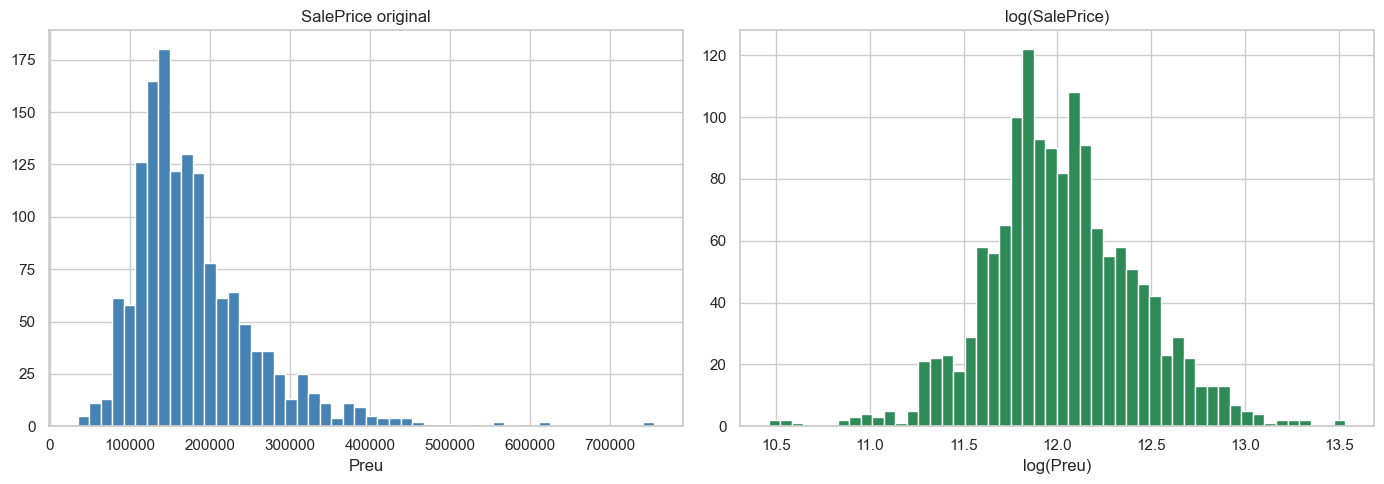

Skewness original: 1.88
Skewness log:      0.12


In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Original — veuràs skew
train['SalePrice'].hist(bins=50, ax=ax1, color='steelblue')
ax1.set_title('SalePrice original')
ax1.set_xlabel('Preu')

# Log — molt més normal
np.log1p(train['SalePrice']).hist(bins=50, ax=ax2, color='seagreen')
ax2.set_title('log(SalePrice)')
ax2.set_xlabel('log(Preu)')

plt.tight_layout()
plt.show()

print(f"Skewness original: {train['SalePrice'].skew():.2f}")
print(f"Skewness log:      {np.log1p(train['SalePrice']).skew():.2f}")

              nuls     %
PoolQC        1453  99.5
MiscFeature   1406  96.3
Alley         1369  93.8
Fence         1179  80.8
MasVnrType     872  59.7
FireplaceQu    690  47.3
LotFrontage    259  17.7
GarageType      81   5.5
GarageYrBlt     81   5.5
GarageFinish    81   5.5
GarageQual      81   5.5
GarageCond      81   5.5
BsmtFinType2    38   2.6
BsmtExposure    38   2.6
BsmtFinType1    37   2.5
BsmtCond        37   2.5
BsmtQual        37   2.5
MasVnrArea       8   0.5
Electrical       1   0.1


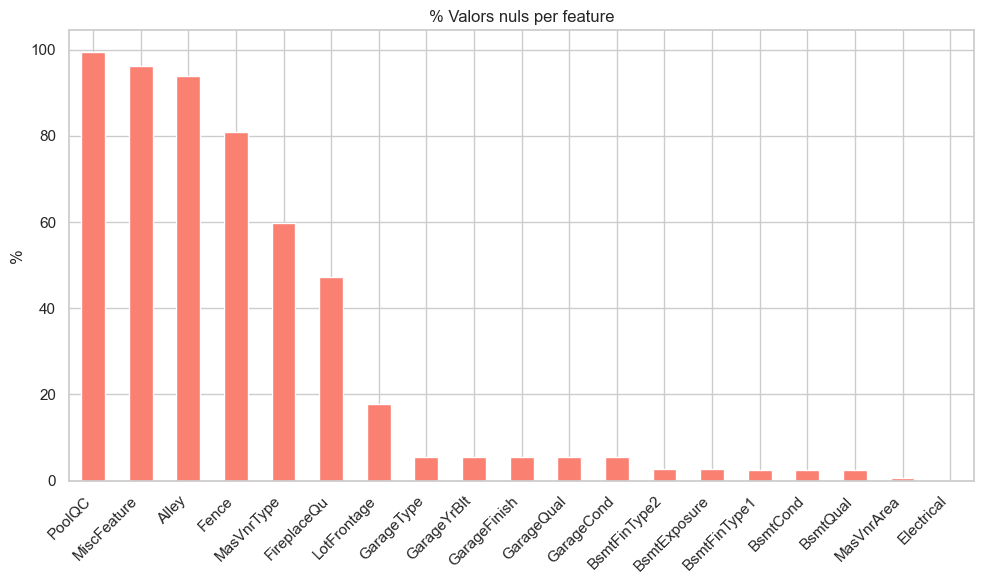

In [7]:
nulls = train.isnull().sum()
nulls = nulls[nulls > 0].sort_values(ascending=False)
pct = (nulls / len(train) * 100).round(1)

null_df = pd.DataFrame({'nuls': nulls, '%': pct})
print(null_df)

# Visualització
plt.figure(figsize=(10, 6))
pct.plot(kind='bar', color='salmon')
plt.title('% Valors nuls per feature')
plt.ylabel('%')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

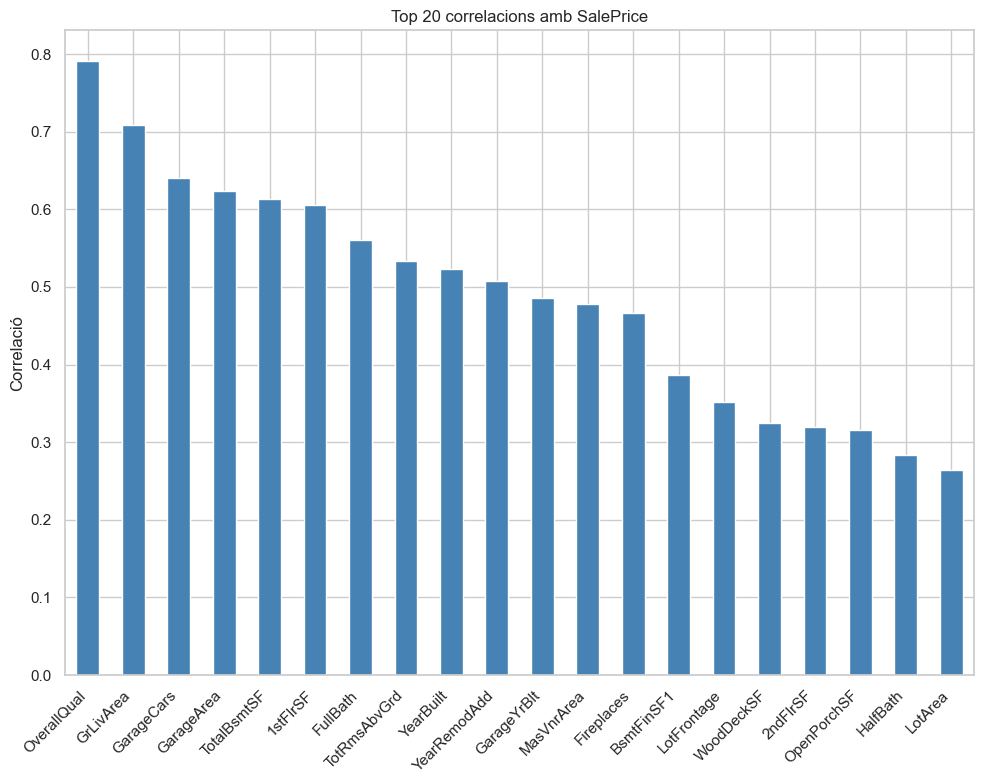

OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
Name: SalePrice, dtype: float64


In [8]:
corr = train.corr(numeric_only=True)['SalePrice'].sort_values(ascending=False)

plt.figure(figsize=(10, 8))
corr[1:21].plot(kind='bar', color='steelblue')  # top 20, excloem SalePrice mateix
plt.title('Top 20 correlacions amb SalePrice')
plt.ylabel('Correlació')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(corr[1:11])  # top 10 en text